# Machine Learning Zoomcamp 2024
## Homework №4


In [106]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

%matplotlib inline

In [107]:
url = 'https://raw.githubusercontent.com/samiralikperov/ml-portfolio/refs/heads/main/Zoomcamp/04-evaluation/bank-full.csv'
df = pd.read_csv(url, sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Dataset preparation.
For the rest of the homework, you'll need to use only these columns:

- 'age',  
- 'job',  
- 'marital',  
- 'education',  
- 'balance',  
- 'housing',  
- 'contact',  
- 'day',  
- 'month',  
- 'duration',  
- 'campaign',  
- 'pdays',  
- 'previous',  
- 'poutcome',  
- 'y'.

*Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use train_test_split function for that with random_state=1*

In [108]:
columns = ['age','job','marital','education','balance','housing','contact','day','month','duration','campaign','pdays','previous','poutcome','y']
df_col = df.copy()[columns]
df_col.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,no


In [109]:
# Target encoding

df_col.y = (df_col.y == 'yes').astype(int)
df_col.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,0


In [110]:
df_col.y

,y
0,0
1,0
2,0
3,0
4,0
...,...
45206,1
45207,1
45208,1
45209,0


In [111]:
# split the dataset.
df_full_train, df_test = train_test_split(df_col, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.y.values
y_val = df_val.y.values
y_test = df_test.y.values

del df_train["y"]
del df_val["y"]
del df_test["y"]

In [112]:
len(df_full_train), len(df_test)

(36168, 9043)

In [113]:
len(df_train), len(df_val)

(27126, 9042)

In [114]:
df_full_train.y.value_counts(normalize= True)

,proportion
y,
0,0.882797
1,0.117203


# Question 1: ROC AUC feature importance
*ROC AUC could also be used to evaluate feature importance of numerical variables.*

Let's do that
- For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
- Use the training dataset for that

If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['engine_hp'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.  

## Which numerical variable (among the following 4) has the highest AUC?

- balance
- day
- duration
- previous


In [115]:
numerical = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [116]:
# roc_auc_score for numerical.
auc_values = {}

for s in numerical:
    auc = roc_auc_score(y_train, df_train[s])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[s])
    auc_values[s] = auc
    print(f"feature: {s}, auc={auc:.3f}")

feature: age, auc=0.512
feature: balance, auc=0.589
feature: day, auc=0.526
feature: duration, auc=0.815
feature: campaign, auc=0.571
feature: pdays, auc=0.590
feature: previous, auc=0.599


# Question 2: Training the model.
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

```LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)```

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.69
- 0.79
- 0.89
- 0.99

In [117]:
categorical = ['job', 'marital', 'education', 'housing', 'contact', 'month', 'poutcome']

In [118]:
# logistic regression model.
columns = numerical + categorical

dv = DictVectorizer(sparse=False)
train_dicts = df_train[columns].to_dict(orient='records')
val_dicts = df_val[columns].to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

In [119]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]
the_score = roc_auc_score(y_val, y_pred)

In [120]:
print(round(the_score, 2))

0.9


# Question 3: Precision and Recall

Now let's compute precision and recall for our model.

- Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
- For each threshold, compute precision and recall
- Plot them


### At which threshold precision and recall curves intersect?

- 0.265
- 0.465
- 0.665
- 0.865

     threshold    tp    fp    fn    tn
0          0.0  1098  7944     0     0
10         0.1   926  1493   172  6451
20         0.2   712   693   386  7251
30         0.3   566   407   532  7537
40         0.4   462   272   636  7672
50         0.5   373   192   725  7752
60         0.6   290   137   808  7807
70         0.7   225   101   873  7843
80         0.8   148    67   950  7877
90         0.9    76    27  1022  7917
100        1.0     0     0  1098  7944


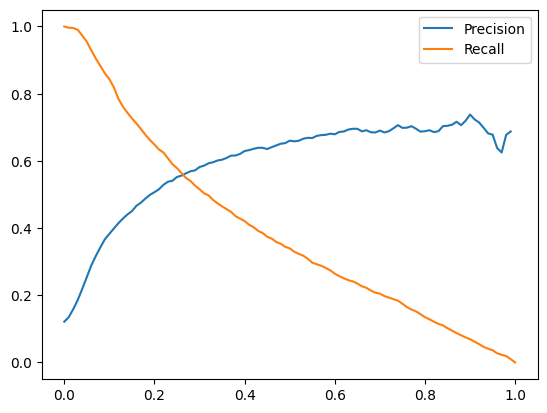

In [121]:
# Define a function
def confusion_matrix_dataframe(y_val, y_pred):
    scores = []

    # thresholds from 0 to 1.
    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        # positives and negatives.
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)


        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)


        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()


        scores.append((t, tp, fp, fn, tn))


    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    return df_scores


df_scores = confusion_matrix_dataframe(y_val, y_pred)

print(df_scores[::10])

df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)

# precision and recall against thresholds.
plt.plot(df_scores.threshold, df_scores.precision, label='Precision')
plt.plot(df_scores.threshold, df_scores.recall, label='Recall')

plt.legend()
plt.show()


# Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:F1 score = 2 * P * R / (P + R)



Where P is precision and R is recall.


Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01



### At which threshold F1 is maximal?

- 0.02
- 0.22
- 0.42
- 0.62

In [122]:
# calculate the F1
df_scores['f1'] = 2 * df_scores.precision * df_scores.recall / (df_scores.precision + df_scores.recall)
best_f1_score = df_scores.loc[df_scores['f1'] == df_scores['f1'].max()]
print(best_f1_score)


    threshold   tp   fp   fn    tn  precision    recall       f1
22       0.22  686  611  412  7333   0.528913  0.624772  0.57286


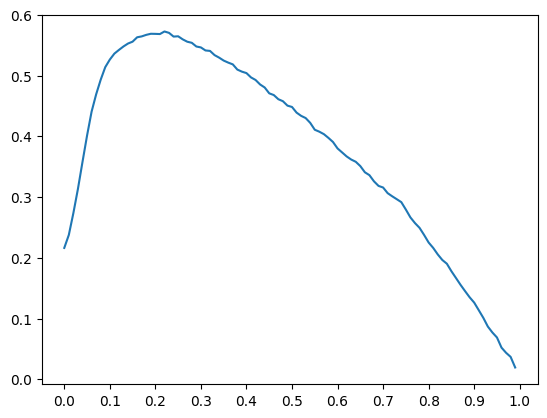

In [123]:
#check
plt.plot(df_scores.threshold, df_scores.f1)
plt.xticks(np.linspace(0, 1, 11))
plt.show()


# Question 5: 5-Fold CV

Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

```KFold(n_splits=5, shuffle=True, random_state=1)```

- Iterate over different folds of df_full_train
- Split the data into train and validation
- Train the model on train with these parameters: ```LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)```
- Use AUC to evaluate the model on validation


### How large is standard deviation of the scores across different folds?

- 0.0001
- 0.006
- 0.06
- 0.26

In [124]:
# to train the model and get feature
def train(df_train, y_train, C=1.0):

    dicts = df_train[columns].to_dict(orient='records')


    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)


    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [125]:
# function to predict probabilities
def predict(df, dv, model):

    dicts = df[columns].to_dict(orient='records')


    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]  # probabilities for the positive class

    return y_pred

In [126]:
# a list to store AUC scores.
scores = []

kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.y
    y_val = df_val.y

    dv, model = train(df_train, y_train, C=1.0)  # train the model.
    y_pred = predict(df_val, dv, model)           # get predictions.

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.5f ± %.5f' % (np.mean(scores), np.std(scores)))


0.90586 ± 0.00565


# Question 6: Hyperparameter Tuning
Now let's use 5-Fold cross-validation to find the best parameter C

- Iterate over the following C values: [0.000001, 0.001, 1]
- Initialize KFold with the same parameters as previously
- Use these parameters for the model: ```LogisticRegression(solver='liblinear', C=C, max_iter=1000)```
- Compute the mean score as well as the std (round the mean and std to 3 decimal digits)


### Which C leads to the best mean score?

- 0.000001
- 0.001
- 1

In [127]:
#K-Fold cross-validation with specified regularization values.
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

regularization_values = [0.000001, 0.001, 1]

for regularization in regularization_values:
    auc_scores = []


    for train_indices, val_indices in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_indices]
        df_val = df_full_train.iloc[val_indices]

        y_train = df_train.y
        y_val = df_val.y

        dv, model = train(df_train, y_train, C=regularization)  # train the model
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)  # calculate the AUC score
        auc_scores.append(auc)

    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)
    print('C=%.6f, Mean AUC=%.5f ± %.5f' % (regularization, mean_auc, std_auc))


C=0.000001, Mean AUC=0.70144 ± 0.00944
C=0.001000, Mean AUC=0.86084 ± 0.00718
C=1.000000, Mean AUC=0.90586 ± 0.00565
